===== BEFORE TUNING =====
Decision Tree Accuracy: 0.9853658536585366
Random Forest Accuracy: 0.9853658536585366


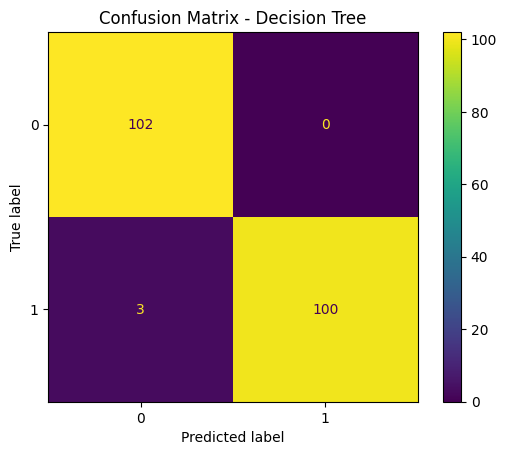

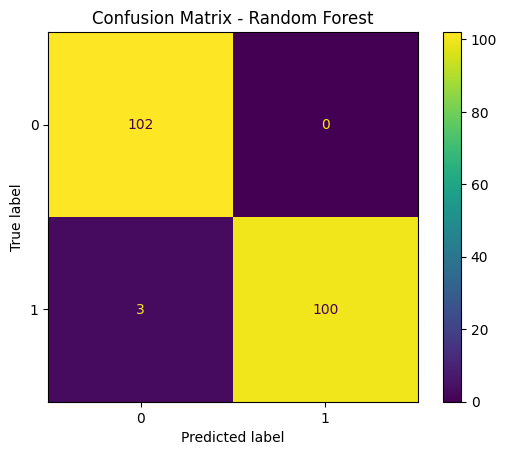

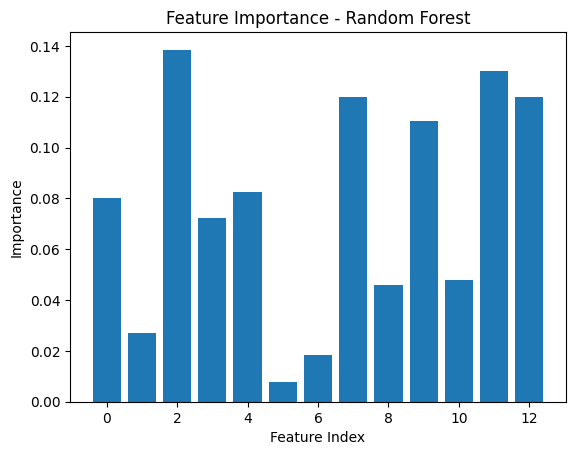


===== AFTER TUNING =====
Decision Tree Tuned Accuracy: 0.9853658536585366
Random Forest Tuned Accuracy: 0.9853658536585366


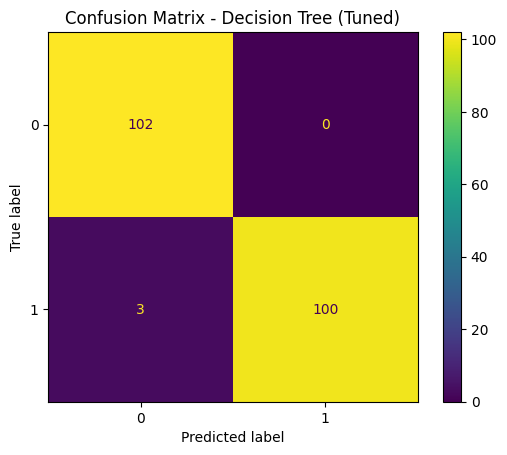

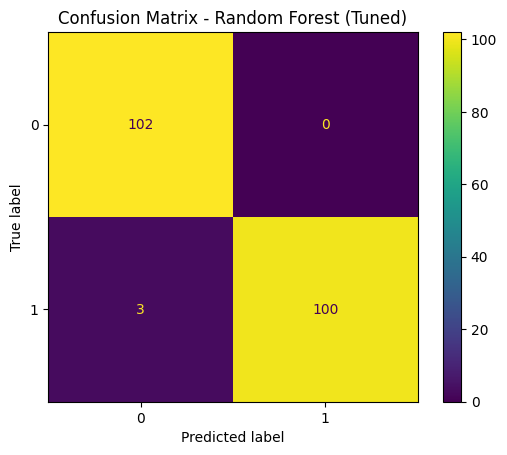

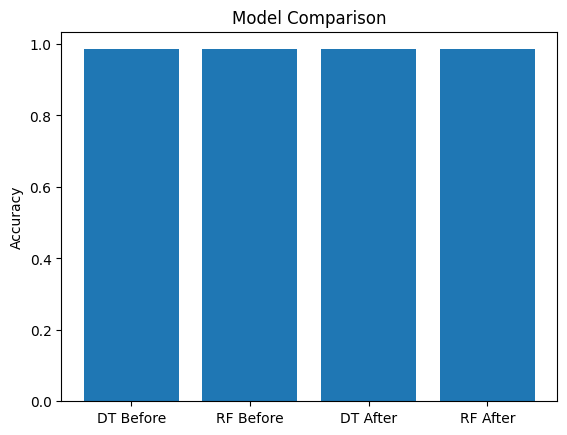

In [2]:
# ==========================================
# HEART DISEASE - DT + RF (FINAL FIXED VERSION)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_csv('/content/heart.csv')

X = df.drop('target', axis=1)
y = df['target']

# ==========================================
# SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# ===== BEFORE TUNING =====
# ==========================================
print("===== BEFORE TUNING =====")

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

# ==========================================
# CONFUSION MATRIX - DECISION TREE
# ==========================================
cm_dt = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# ==========================================
# CONFUSION MATRIX - RANDOM FOREST
# ==========================================
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ==========================================
# FEATURE IMPORTANCE - RANDOM FOREST
# ==========================================
importances = rf.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# ==========================================
# ===== HYPERPARAMETER TUNING =====
# ==========================================

# Decision Tree tuning
dt_params = {"max_depth": [3, 5, 10]}
dt_cv = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5)
dt_cv.fit(X_train, y_train)

# Random Forest tuning
rf_params = {"n_estimators": [50, 100], "max_depth": [3, 5, 10]}
rf_cv = GridSearchCV(RandomForestClassifier(), rf_params, cv=5)
rf_cv.fit(X_train, y_train)

# ==========================================
# ===== AFTER TUNING =====
# ==========================================
print("\n===== AFTER TUNING =====")

dt_best = dt_cv.best_estimator_
rf_best = rf_cv.best_estimator_

dt_pred2 = dt_best.predict(X_test)
rf_pred2 = rf_best.predict(X_test)

dt_acc2 = accuracy_score(y_test, dt_pred2)
rf_acc2 = accuracy_score(y_test, rf_pred2)

print("Decision Tree Tuned Accuracy:", dt_acc2)
print("Random Forest Tuned Accuracy:", rf_acc2)

# ==========================================
# CONFUSION MATRIX - DT TUNED
# ==========================================
cm_dt2 = confusion_matrix(y_test, dt_pred2)
ConfusionMatrixDisplay(cm_dt2).plot()
plt.title("Confusion Matrix - Decision Tree (Tuned)")
plt.show()

# ==========================================
# CONFUSION MATRIX - RF TUNED
# ==========================================
cm_rf2 = confusion_matrix(y_test, rf_pred2)
ConfusionMatrixDisplay(cm_rf2).plot()
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.show()

# ==========================================
# ACCURACY COMPARISON GRAPH
# ==========================================
labels = ["DT Before", "RF Before", "DT After", "RF After"]
values = [dt_acc, rf_acc, dt_acc2, rf_acc2]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


========== BEFORE TUNING ==========

--- Decision Tree ---
Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



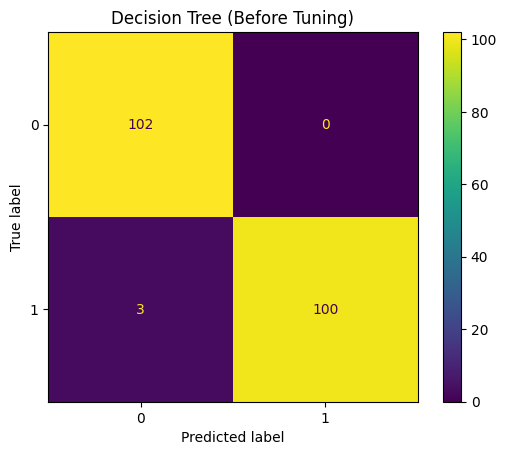


--- Random Forest ---
Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



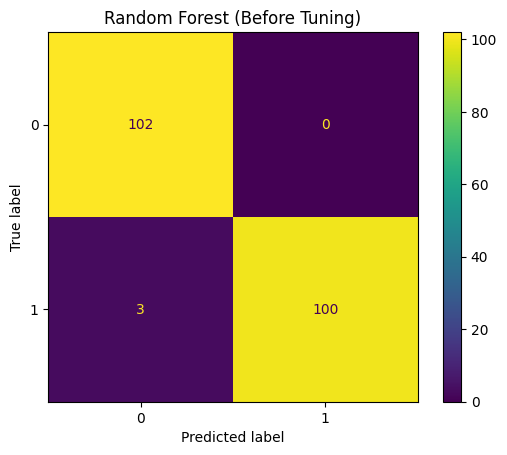

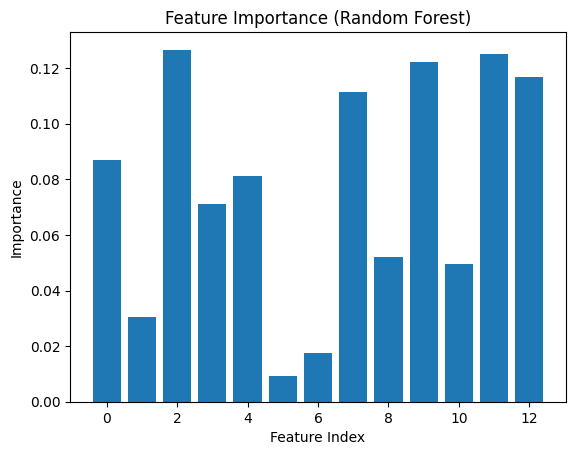


========== HYPERPARAMETER TUNING ==========
Best DT Params: {'max_depth': 10}
Best RF Params: {'max_depth': 10, 'n_estimators': 50}

========== AFTER TUNING ==========

--- Decision Tree (Tuned) ---
Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



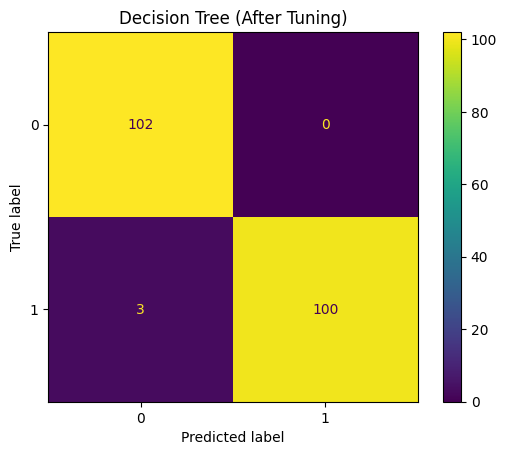


--- Random Forest (Tuned) ---
Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



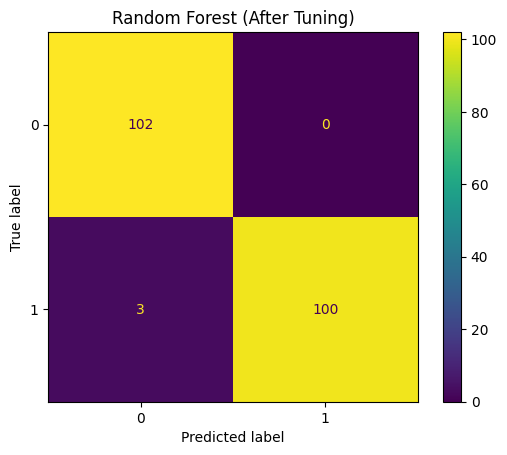

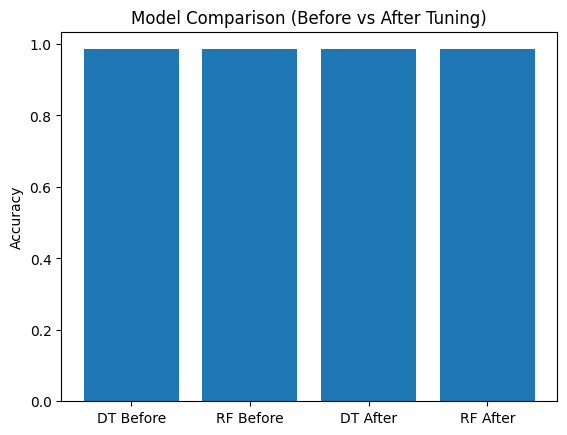

In [3]:
# ==========================================
# HEART DISEASE - DT + RF (FULL A-Z FINAL)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_csv('/content/heart.csv')

X = df.drop('target', axis=1)
y = df['target']

# ==========================================
# SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# ===== BEFORE TUNING =====
# ==========================================
print("\n========== BEFORE TUNING ==========")

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("\n--- Decision Tree ---")
dt_acc = accuracy_score(y_test, dt_pred)
print("Accuracy:", dt_acc)
print(classification_report(y_test, dt_pred))

# Confusion Matrix DT
cm_dt = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(cm_dt).plot()
plt.title("Decision Tree (Before Tuning)")
plt.show()

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n--- Random Forest ---")
rf_acc = accuracy_score(y_test, rf_pred)
print("Accuracy:", rf_acc)
print(classification_report(y_test, rf_pred))

# Confusion Matrix RF
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest (Before Tuning)")
plt.show()

# ==========================================
# FEATURE IMPORTANCE (RF)
# ==========================================
importances = rf.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# ==========================================
# ===== HYPERPARAMETER TUNING =====
# ==========================================
print("\n========== HYPERPARAMETER TUNING ==========")

# Decision Tree tuning
dt_params = {"max_depth": [3, 5, 10, None]}
dt_cv = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5)
dt_cv.fit(X_train, y_train)

print("Best DT Params:", dt_cv.best_params_)

# Random Forest tuning
rf_params = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 10]
}
rf_cv = GridSearchCV(RandomForestClassifier(), rf_params, cv=5)
rf_cv.fit(X_train, y_train)

print("Best RF Params:", rf_cv.best_params_)

# ==========================================
# ===== AFTER TUNING =====
# ==========================================
print("\n========== AFTER TUNING ==========")

# Tuned DT
dt_best = dt_cv.best_estimator_
dt_pred2 = dt_best.predict(X_test)

print("\n--- Decision Tree (Tuned) ---")
dt_acc2 = accuracy_score(y_test, dt_pred2)
print("Accuracy:", dt_acc2)
print(classification_report(y_test, dt_pred2))

cm_dt2 = confusion_matrix(y_test, dt_pred2)
ConfusionMatrixDisplay(cm_dt2).plot()
plt.title("Decision Tree (After Tuning)")
plt.show()

# Tuned RF
rf_best = rf_cv.best_estimator_
rf_pred2 = rf_best.predict(X_test)

print("\n--- Random Forest (Tuned) ---")
rf_acc2 = accuracy_score(y_test, rf_pred2)
print("Accuracy:", rf_acc2)
print(classification_report(y_test, rf_pred2))

cm_rf2 = confusion_matrix(y_test, rf_pred2)
ConfusionMatrixDisplay(cm_rf2).plot()
plt.title("Random Forest (After Tuning)")
plt.show()

# ==========================================
# ===== ACCURACY COMPARISON GRAPH =====
# ==========================================
labels = ["DT Before", "RF Before", "DT After", "RF After"]
values = [dt_acc, rf_acc, dt_acc2, rf_acc2]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Before vs After Tuning)")
plt.show()

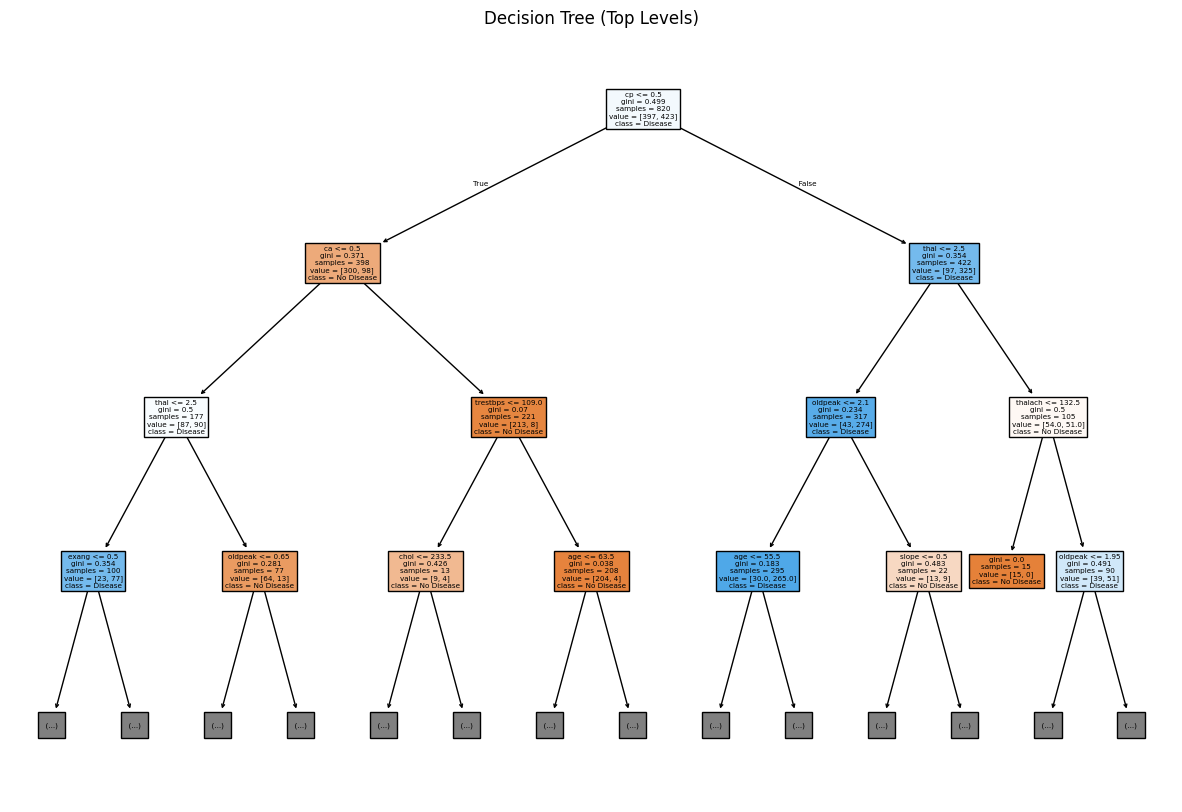

In [4]:
from sklearn.tree import plot_tree

# ==========================================
# DECISION TREE VISUALIZATION
# ==========================================
plt.figure(figsize=(15,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    max_depth=3   # IMPORTANT: keeps tree readable
)
plt.title("Decision Tree (Top Levels)")
plt.show()